In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
N = 100

folder_path = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026"

all_files = {
    1: "Joint_1_Clean.csv",
    2: "Joint_2_Clean.csv",
    3: "Joint_3_Clean.csv",
    5: "Joint_5_Clean.csv"
}

In [3]:
def lugre_steady_state_friction(v, Fc, Fs, vs, sigma_2):
    """
    Steady-state LuGre friction model based on the PINN paper formulation.
    At constant velocity (dz/dt = 0), the dynamic parameters (sigma_0, sigma_1)
    drop out leaving the steady-state parameters:
    Fc      : Coulomb friction 
    Fs      : Static friction
    vs      : Stribeck velocity
    sigma_2 : Viscous damping coefficient
    """
    # alpha is typically set to 2 in the LuGre model (as noted in the paper)
    alpha = 2
    
    # Calculate the Stribeck effect function g(v)
    g_v = Fc + (Fs - Fc) * np.exp(-(np.abs(v) / vs)**alpha)
    
    # Return the steady-state friction torque/force
    return g_v * np.sign(v) + sigma_2 * v

JOINT 1
Columns:
['timestamp', 'm_t_1', 'jts1', 'v1', 'q1'] 

Train : (33085,)
Val   : (4727,)
Test  : (9453,)

Estimated Parameters
Fc (Coulomb)      = 0.084854
Fs (Static)       = 5.461425
Vs (Stribeck vel) = 0.000413
Sigma_2 (Viscous) = 0.003341

Validation R² = 0.9876

Performance
RMSE = 0.0210
MAE  = 0.0150
R²   = 0.9880



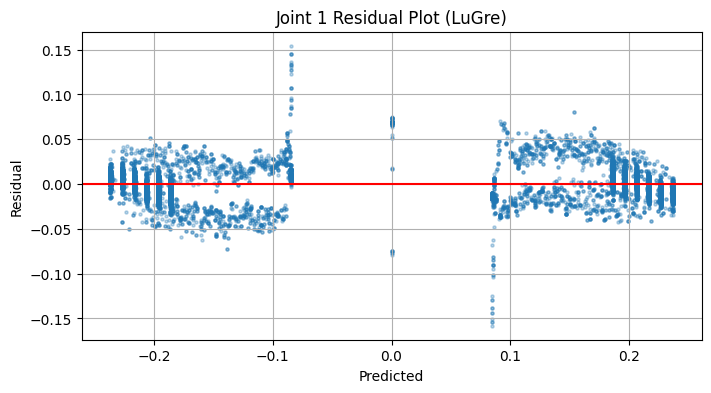

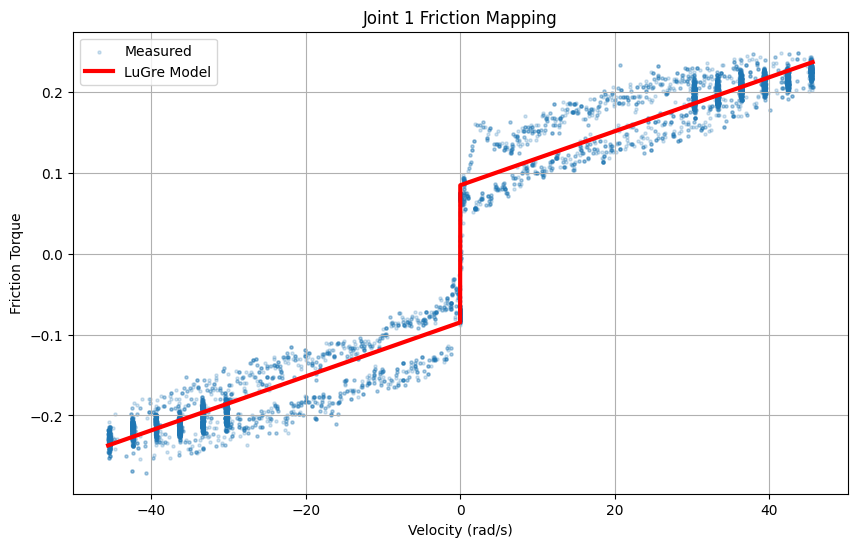

JOINT 2
Columns:
['timestamp', 'm_t_2', 'jts2', 'v2', 'q2'] 

Train : (2890,)
Val   : (413,)
Test  : (826,)

Estimated Parameters
Fc (Coulomb)      = 0.000000
Fs (Static)       = 0.074907
Vs (Stribeck vel) = 0.001072
Sigma_2 (Viscous) = 0.004523

Validation R² = 0.0119

Performance
RMSE = 0.5484
MAE  = 0.4746
R²   = 0.0172



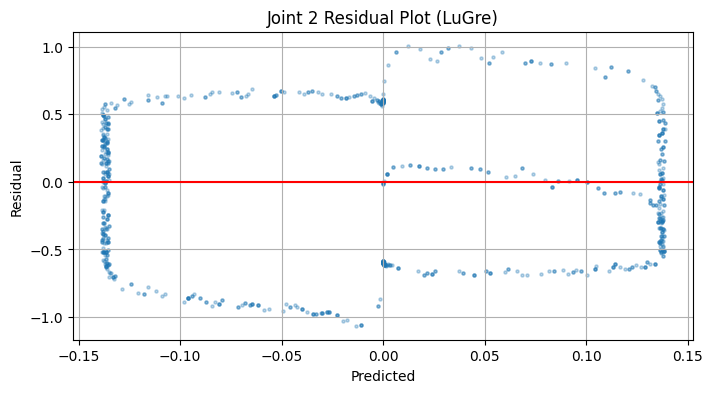

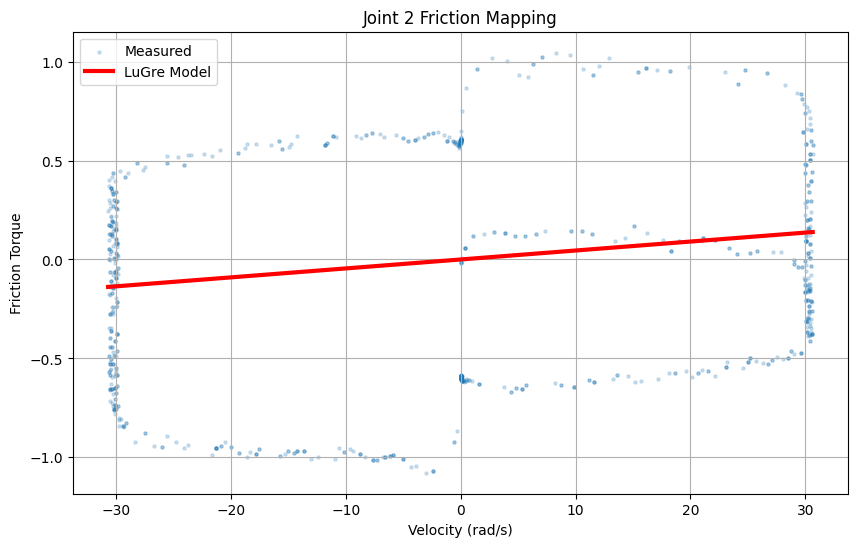

JOINT 3
Columns:
['timestamp', 'm_t_3', 'jts3', 'v3', 'q3'] 

Train : (8120,)
Val   : (1161,)
Test  : (2321,)

Estimated Parameters
Fc (Coulomb)      = 0.000000
Fs (Static)       = 106301.655665
Vs (Stribeck vel) = 0.006684
Sigma_2 (Viscous) = 0.002526

Validation R² = 0.0834

Performance
RMSE = 0.2597
MAE  = 0.2370
R²   = 0.0809



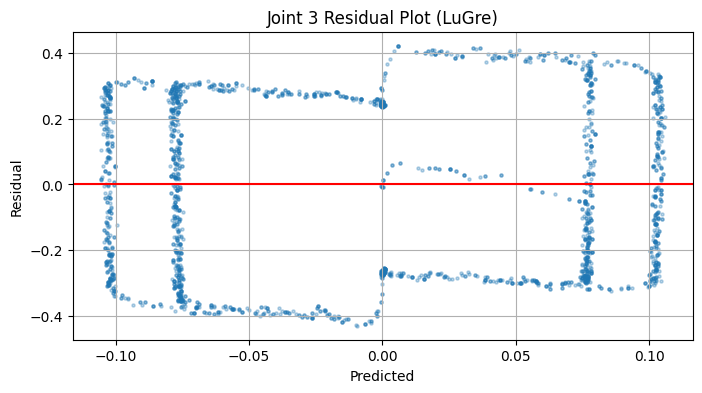

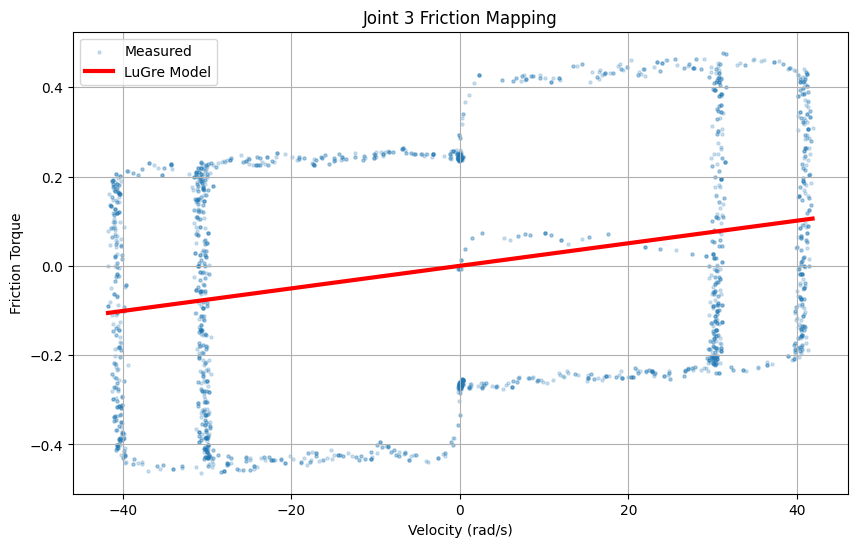

JOINT 5
Columns:
['timestamp', 'm_t_5', 'jts5', 'v5', 'q5'] 

Train : (22415,)
Val   : (3203,)
Test  : (6405,)

Estimated Parameters
Fc (Coulomb)      = 0.013613
Fs (Static)       = 16.516846
Vs (Stribeck vel) = 0.000090
Sigma_2 (Viscous) = 0.000771

Validation R² = 0.5054

Performance
RMSE = 0.0361
MAE  = 0.0323
R²   = 0.4904



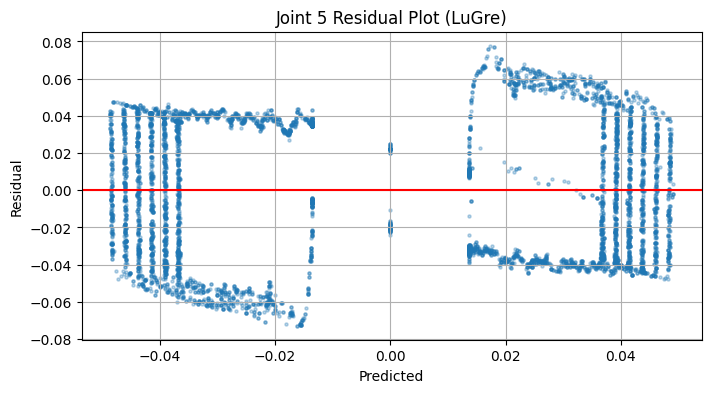

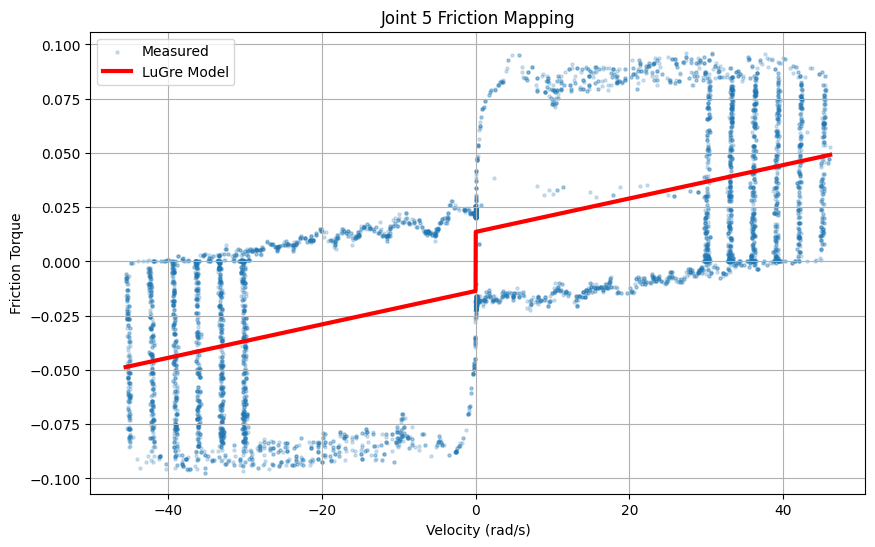

In [4]:
for joint, filename in all_files.items():
    print("="*70)
    print(f"JOINT {joint}")
    print("="*70)
    
    # 1. Load Data
    file_path = os.path.join(folder_path, filename)
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File {filename} not found. Skipping...")
        continue
    
    # Fallback assignment based on your standard columns ['m_t_1', 'jts1', 'v1', 'q1']
    v_col = f'v{joint}'
    t_col = f'm_t_{joint}'
    
    if v_col not in df.columns or t_col not in df.columns:
        v_col = df.columns[2]
        t_col = df.columns[0]
        
    X = df[v_col].values
    y = df[t_col].values
    
    # 2. Train/Val/Test Split
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # Split the remaining 80% to get ~10% for validation and ~70% for train
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42) 
    
    print("Columns:")
    print(list(df.columns), "\n")
    print(f"Train : {X_train.shape}")
    print(f"Val   : {X_val.shape}")
    print(f"Test  : {X_test.shape}\n")
    
    # 3. Curve Fitting for LuGre
    # Sensible bounds and initial guesses prevent the solver from failing on the exponential
    # Initial Guess: [Fc, Fs, vs, sigma_2]
    initial_guess = [5.0, 10.0, 0.1, 15.0] 
    bounds = (0, [np.inf, np.inf, np.inf, np.inf]) # Physical constraints: parameters must be positive
    
    try:
        popt, pcov = curve_fit(lugre_steady_state_friction, X_train, y_train, p0=initial_guess, bounds=bounds, maxfev=10000)
        Fc_est, Fs_est, vs_est, sigma2_est = popt
        
        print("Estimated Parameters")
        print(f"Fc (Coulomb)      = {Fc_est:.6f}")
        print(f"Fs (Static)       = {Fs_est:.6f}")
        print(f"Vs (Stribeck vel) = {vs_est:.6f}")
        print(f"Sigma_2 (Viscous) = {sigma2_est:.6f}\n")
        
        # 4. Validation Metrics
        val_pred = lugre_steady_state_friction(X_val, *popt)
        val_r2 = r2_score(y_val, val_pred)
        print(f"Validation R² = {val_r2:.4f}\n")
        
        # 5. Testing Metrics
        pred = lugre_steady_state_friction(X_test, *popt)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)
        
        print("Performance")
        print(f"RMSE = {rmse:.4f}")
        print(f"MAE  = {mae:.4f}")
        print(f"R²   = {r2:.4f}\n")
        
        # ==========================================
        # PLOT 1: Residual Plot
        # ==========================================
        residual = y_test - pred
        plt.figure(figsize=(8,4))
        plt.scatter(pred, residual, s=5, alpha=0.3)
        plt.axhline(0, color="red")
        plt.xlabel("Predicted")
        plt.ylabel("Residual")
        plt.title(f"Joint {joint} Residual Plot (LuGre)")
        plt.grid(True)
        plt.show()

        # ==========================================
        # PLOT 2: Friction Curve
        # ==========================================
        idx = np.argsort(X_test.ravel())
        plt.figure(figsize=(10,6))
        plt.scatter(X_test.ravel(), y_test, s=5, alpha=0.2, label="Measured")
        plt.plot(X_test.ravel()[idx], pred[idx], color='red', linewidth=3, label="LuGre Model")
        plt.xlabel("Velocity (rad/s)")
        plt.ylabel("Friction Torque")
        plt.title(f"Joint {joint} Friction Mapping")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    except Exception as e:
        print(f"LuGre Curve fitting failed for Joint {joint}: {e}")

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensure TensorFlow uses float32 globally for consistent gradients
tf.keras.backend.set_floatx('float32')

In [7]:
class LuGrePINN(tf.keras.Model):
    def __init__(self):
        super(LuGrePINN, self).__init__()
        
        # 4 Hidden Layers with 128 neurons each, ReLU activation (as per the paper)
        self.d1 = tf.keras.layers.Dense(128, activation='relu')
        self.d2 = tf.keras.layers.Dense(128, activation='relu')
        self.d3 = tf.keras.layers.Dense(128, activation='relu')
        self.d4 = tf.keras.layers.Dense(128, activation='relu')
        
        # Output layer for internal bristle state (z)
        self.z_out = tf.keras.layers.Dense(1, activation='linear')
        
        # Physics Parameters initialized as trainable variables
        self.sigma_0_var = tf.Variable(1000.0, trainable=True, dtype=tf.float32)
        self.sigma_1_var = tf.Variable(10.0, trainable=True, dtype=tf.float32)
        self.sigma_2_var = tf.Variable(0.1, trainable=True, dtype=tf.float32)
        self.fc_var = tf.Variable(0.1, trainable=True, dtype=tf.float32)
        self.fs_var = tf.Variable(0.5, trainable=True, dtype=tf.float32)
        self.vs_var = tf.Variable(0.05, trainable=True, dtype=tf.float32)

    def call(self, v):
        x = self.d1(v)
        x = self.d2(x)
        x = self.d3(x)
        x = self.d4(x)
        return self.z_out(x)

    def get_physics_params(self):
        # Enforce physical constraints: parameters must be strictly positive
        s0 = tf.math.abs(self.sigma_0_var) + 1e-4
        s1 = tf.math.abs(self.sigma_1_var) + 1e-4
        s2 = tf.math.abs(self.sigma_2_var) + 1e-4
        fc = tf.math.abs(self.fc_var) + 1e-4
        fs = tf.math.abs(self.fs_var) + 1e-4
        vs = tf.math.abs(self.vs_var) + 1e-4
        
        # Ensure static friction is always >= Coulomb friction
        fs = tf.maximum(fs, fc + 1e-4) 
        
        return s0, s1, s2, fc, fs, vs


🚀 INITIALIZING PINN FOR JOINT 1 | FILE: Joint_1_Clean.csv
Training started for Joint 1. Data points: 33085...
   Epoch 0500 | Total Loss: 1666824.2500 | Data Loss (MSE): 10.2349
   Epoch 1000 | Total Loss: 28286516.0000 | Data Loss (MSE): 10.2273
   Epoch 1500 | Total Loss: 486507.6250 | Data Loss (MSE): 10.2222
   Epoch 2000 | Total Loss: 80770456.0000 | Data Loss (MSE): 10.2205

----------------------------------------
🏆 JOINT 1 RESULTS
----------------------------------------
Sigma_0 (Stiffness) = 1000.0001
Sigma_1 (Damping)   = 10.0001
Sigma_2 (Viscous)   = 0.1001
Fc (Coulomb)        = 0.1001
Fs (Static)         = 0.5001
Vs (Stribeck Vel)   = 0.0501
Test R²             = -285.7884
Test RMSE           = 3.2466


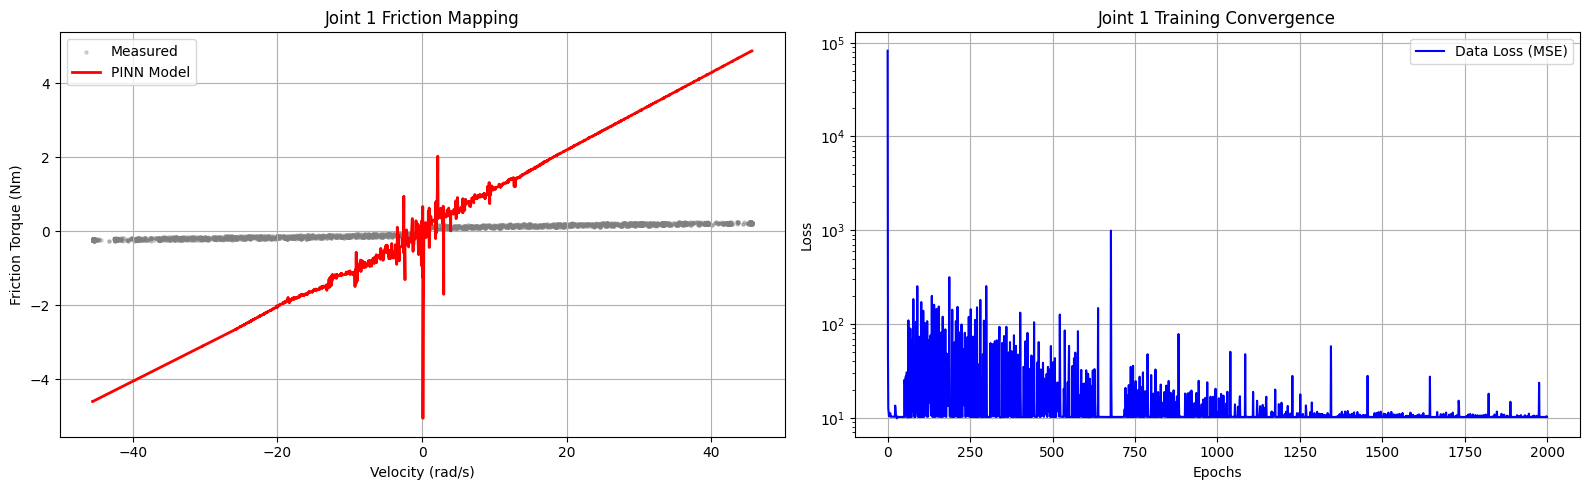


🚀 INITIALIZING PINN FOR JOINT 2 | FILE: Joint_2_Clean.csv
Training started for Joint 2. Data points: 2890...
   Epoch 0500 | Total Loss: 4524722.5000 | Data Loss (MSE): 5.8768
   Epoch 1000 | Total Loss: 993062.8125 | Data Loss (MSE): 5.8596
   Epoch 1500 | Total Loss: 33034360.0000 | Data Loss (MSE): 5.9043
   Epoch 2000 | Total Loss: 954361.3125 | Data Loss (MSE): 5.8574

----------------------------------------
🏆 JOINT 2 RESULTS
----------------------------------------
Sigma_0 (Stiffness) = 1000.0001
Sigma_1 (Damping)   = 10.0001
Sigma_2 (Viscous)   = 0.1001
Fc (Coulomb)        = 0.1001
Fs (Static)         = 0.5001
Vs (Stribeck Vel)   = 0.0501
Test R²             = -17.8412
Test RMSE           = 2.4011


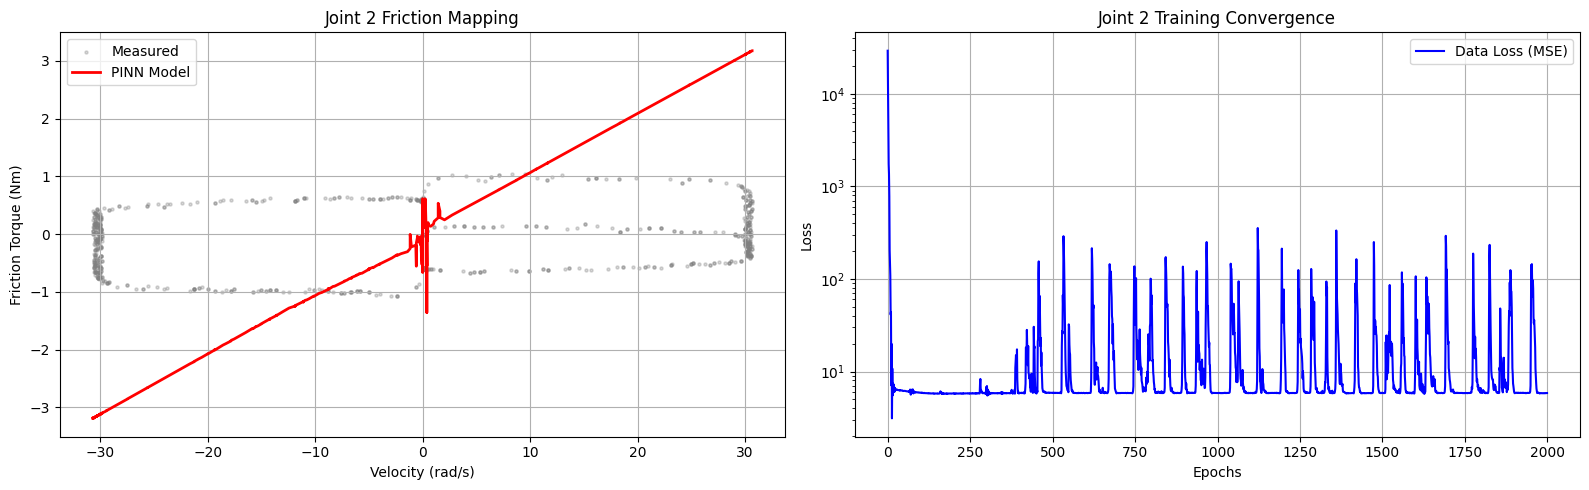


🚀 INITIALIZING PINN FOR JOINT 3 | FILE: Joint_3_Clean.csv
Training started for Joint 3. Data points: 8120...
   Epoch 0500 | Total Loss: 1296.2972 | Data Loss (MSE): 8.8443
   Epoch 1000 | Total Loss: 724345.1875 | Data Loss (MSE): 8.8432


In [ ]:
# ---------------------------------------------------------
# SETUP DIRECTORIES AND FILES
# ---------------------------------------------------------
folder_path = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026"
all_files = {
    1: "Joint_1_Clean.csv",
    2: "Joint_2_Clean.csv",
    3: "Joint_3_Clean.csv",
    5: "Joint_5_Clean.csv"
}

# Hyperparameters
epochs = 2000          # Increase to 5000-10000 if convergence isn't flat yet
batch_size = 512
lambda_phy = 1e5       # Scaling factor from the paper

# Dictionary to store performance for review later
results_summary = {}

for joint, filename in all_files.items():
    print("\n" + "="*80)
    print(f"🚀 INITIALIZING PINN FOR JOINT {joint} | FILE: {filename}")
    print("="*80)
    
    file_path = os.path.join(folder_path, filename)
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File {filename} not found. Skipping...")
        continue
        
    # ---------------------------------------------------------
    # 1. DATA PREPROCESSING & PHYSICS DERIVATIVES
    # ---------------------------------------------------------
    # Parse timestamp to calculate physical dt (delta time in seconds)
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='%H:%M:%S.%f', errors='coerce')
    time_sec = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds().values
    
    # Extract Velocity and Friction Torque
    v_col = f'v{joint}'
    t_col = f'm_t_{joint}' # This is torque
    
    v = df[v_col].values
    f_meas = df[t_col].values
    
    # Compute physical acceleration using the time steps
    dt = np.mean(np.diff(time_sec))
    a = np.gradient(v, dt)
    
    # Reshape for TensorFlow
    v_tf = v.reshape(-1, 1).astype(np.float32)
    a_tf = a.reshape(-1, 1).astype(np.float32)
    f_tf = f_meas.reshape(-1, 1).astype(np.float32)
    
    # Train/Val/Test Split (70/10/20)
    v_train_val, v_test, a_train_val, a_test, f_train_val, f_test = train_test_split(v_tf, a_tf, f_tf, test_size=0.2, random_state=42)
    v_train, v_val, a_train, a_val, f_train, f_val = train_test_split(v_train_val, a_train_val, f_train_val, test_size=0.125, random_state=42)
    
    train_dataset = tf.data.Dataset.from_tensor_slices((v_train, a_train, f_train)).shuffle(10000).batch(batch_size)
    
    # ---------------------------------------------------------
    # 2. MODEL INITIALIZATION & CUSTOM TRAINING LOGIC
    # ---------------------------------------------------------
    model = LuGrePINN()
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    
    # Defining train_step inside the loop ties it explicitly to this specific joint's model instance
    @tf.function
    def train_step(v_batch, a_batch, f_batch):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(v_batch)
            
            z = model(v_batch)
            dz_dv = tape.gradient(z, v_batch)
            z_dot_model = dz_dv * a_batch # Chain rule
            
            s0, s1, s2, fc, fs, vs = model.get_physics_params()
            
            # Physics Equations
            g_v = fc + (fs - fc) * tf.exp(-tf.square(tf.abs(v_batch) / vs))
            z_dot_lugre = v_batch - ((s0 * tf.abs(v_batch)) / g_v) * z
            f_pred = s0 * z + s1 * z_dot_model + s2 * v_batch
            
            # Losses
            loss_data = tf.reduce_mean(tf.square(f_batch - f_pred))
            loss_phy = tf.reduce_mean(tf.square(z_dot_model - z_dot_lugre))
            total_loss = loss_data + lambda_phy * loss_phy

        gradients = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        del tape
        return total_loss, loss_data, loss_phy

    # ---------------------------------------------------------
    # 3. TRAINING LOOP
    # ---------------------------------------------------------
    print(f"Training started for Joint {joint}. Data points: {len(v_train)}...")
    history = {'loss': [], 'data_loss': [], 'phy_loss': []}
    
    for epoch in range(epochs):
        epoch_loss_total, epoch_loss_data, epoch_loss_phy, steps = 0, 0, 0, 0
        for v_b, a_b, f_b in train_dataset:
            lt, ld, lp = train_step(v_b, a_b, f_b)
            epoch_loss_total += lt.numpy()
            epoch_loss_data += ld.numpy()
            epoch_loss_phy += lp.numpy()
            steps += 1
            
        history['loss'].append(epoch_loss_total / steps)
        history['data_loss'].append(epoch_loss_data / steps)
        history['phy_loss'].append(epoch_loss_phy / steps)
        
        if (epoch + 1) % 500 == 0:
            print(f"   Epoch {epoch+1:04d} | Total Loss: {history['loss'][-1]:.4f} | Data Loss (MSE): {history['data_loss'][-1]:.4f}")

    # ---------------------------------------------------------
    # 4. EVALUATION & EXTRACTION
    # ---------------------------------------------------------
    s0, s1, s2, fc, fs, vs = [p.numpy() for p in model.get_physics_params()]
    
    v_test_tf = tf.convert_to_tensor(v_test)
    a_test_tf = tf.convert_to_tensor(a_test)
    
    with tf.GradientTape() as tape:
        tape.watch(v_test_tf)
        z_pred = model(v_test_tf)
    dz_dv_test = tape.gradient(z_pred, v_test_tf)
    z_dot_pred = dz_dv_test * a_test_tf
    
    f_test_pred = ((s0 * z_pred) + (s1 * z_dot_pred) + (s2 * v_test_tf)).numpy()
    
    rmse = np.sqrt(mean_squared_error(f_test, f_test_pred))
    r2 = r2_score(f_test, f_test_pred)
    
    results_summary[joint] = {'R2': r2, 'RMSE': rmse, 'Fc': fc, 'Fs': fs}

    print("\n" + "-"*40)
    print(f"🏆 JOINT {joint} RESULTS")
    print("-"*40)
    print(f"Sigma_0 (Stiffness) = {s0:.4f}")
    print(f"Sigma_1 (Damping)   = {s1:.4f}")
    print(f"Sigma_2 (Viscous)   = {s2:.4f}")
    print(f"Fc (Coulomb)        = {fc:.4f}")
    print(f"Fs (Static)         = {fs:.4f}")
    print(f"Vs (Stribeck Vel)   = {vs:.4f}")
    print(f"Test R²             = {r2:.4f}")
    print(f"Test RMSE           = {rmse:.4f}")
    
    # ---------------------------------------------------------
    # 5. PLOTTING
    # ---------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Plot 1: Friction Map
    idx = np.argsort(v_test.ravel())
    ax1.scatter(v_test.ravel(), f_test.ravel(), s=5, alpha=0.3, label="Measured", color='gray')
    ax1.plot(v_test.ravel()[idx], f_test_pred.ravel()[idx], color='red', linewidth=2, label="PINN Model")
    ax1.set_xlabel("Velocity (rad/s)")
    ax1.set_ylabel("Friction Torque (Nm)")
    ax1.set_title(f"Joint {joint} Friction Mapping")
    ax1.legend()
    ax1.grid(True)
    
    # Plot 2: Training Convergence
    ax2.plot(history['data_loss'], label="Data Loss (MSE)", color='blue')
    ax2.set_yscale('log')
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Loss")
    ax2.set_title(f"Joint {joint} Training Convergence")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Final Summary
print("\n" + "="*80)
print("🎯 ALL JOINTS TRAINING COMPLETE - SUMMARY")
print("="*80)
for j, res in results_summary.items():
    print(f"Joint {j} | R²: {res['R2']:.4f} | RMSE: {res['RMSE']:.4f} | Fc: {res['Fc']:.4f} | Fs: {res['Fs']:.4f}")